In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.integrate as integ

import requests
request = requests.get("https://raw.githubusercontent.com/nsfuss/AMOC-Senior-Project/blob/main/functions.py")
with open ("functions.py", "wb") as f:
    f.write(request.content)
from functions import all

mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rc('xtick.minor', visible=True)
mpl.rc('ytick.minor', visible=True)

SyntaxError: illegal target for annotation (functions.py, line 1)


## Goal:

Have H increase linearly w.r.t time and then decrease linearly w.r.t time, graph Q vs T for this scenario. It is unlikely we will see the expected spike as H decreases to the critical point. <br>
Can use the fuctions from the QvsH model to do this
 
Now let $q$ be defined by the differential $\tau \frac{dq}{dt} = -q + k|\alpha \Delta T - \beta \Delta S|$ integrate this to get q as H increases given the known relationship $\frac{d \Delta S}{dt} = 2H - 2|q| \Delta S$ <br>
Need to figure out what $\tau$ should be here, Cyrus guesses in the range of 1-2 centuries

c:\Users\Nathan\Desktop\AMOC Stuff\functions.py:104: RuntimeWarning: invalid value encountered in divide
  q1 = H / (dS[1])


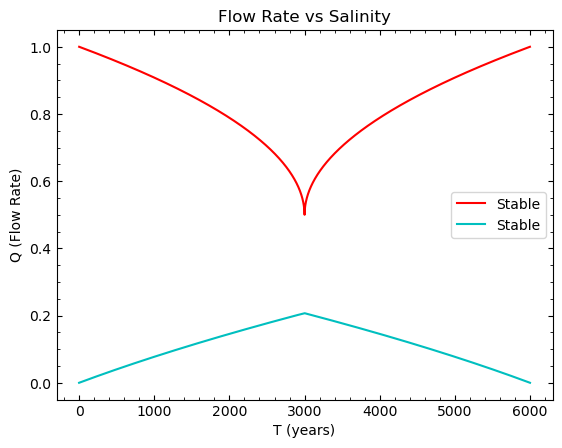

In [15]:
beta = 1
alpha = 1
delT = 1
k = 1
Args = [beta,alpha,delT,k] # Define arguments

H_inc = getH(Args,3000) # List of 3000 equally spaced values of H between 0 and the maximum such that the eq. sol of dDS/dt is real
H_dec = np.flip(H_inc) # Get the decreasing version of this list (max to 0 rather than 0 to max)
H = np.append(H_inc,H_dec) # Append together to get an evenly space list that goes from 0 to the max H in 3000 steps and then back to 0 in another 3000 steps

time = np.arange(0,6000,1) # time array (0,1,2,...,5999) assuming these to be years
qs = q_H(H, Args)

plt.plot(time, qs[1], color='r',label='Stable')
plt.plot(time, qs[2], color='c',label='Stable')
plt.title('Flow Rate vs Salinity')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.legend()


In [ ]:
def dqdt1_inc(t, q, H, args):
    '''
    Equation defining the differential form of q to be solved with the scipy.integrate.solve_ivp function for the first stable equilibirum point

    Parameters:
    t: time
    q: Variable being solved over
    H: array of values, calculated in terms of T, linearly increasing for half and linearly decreasing for the other half
    args: array of floats [beta, alpha, Delta T, k, Tau]
    '''
    return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 - np.sqrt(1/4 - H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) /args[4]

def dqdt1_dec(t, q, args):
    '''
    Equation defining the differential form of q to be solved with the scipy.integrate.solve_ivp function for the first stable equilibirum point

    Parameters:
    t: time
    q: Variable being solved over
    H: array of values, calculated in terms of T, linearly increasing for half and linearly decreasing for the other half
    args: array of floats [beta, alpha, Delta T, k, Tau]
    '''
    return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 - np.sqrt(1/4 - 0.12*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) /args[4]

def dqdt2(t, q, H, args):
    '''
    Equation defining the differential form of q to be solved with the scipy.integrate.solve_ivp function for the second stable equilibrium point

    Parameters:
    t: time
    q: Variable being solved over
    H: array of values, calculated in terms of T, linearly increasing for half and linearly decreasing for the other half
    args: array of floats [beta, alpha, Delta T, k, Tau]
    '''
    return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 + np.sqrt(1/4 + H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) / args[4]

In [23]:
q0_1 = Args[3]*(Args[1]*Args[2] - Args[0]*(Args[1]*Args[2] * (1/2 - np.sqrt(1/4 - H[0]*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0])) # Define the initial value (q at H[0]))
q0_2 = Args[3]*(Args[1]*Args[2] - Args[0]*(Args[1]*Args[2] * (1/2 + np.sqrt(1/4 + H[0]*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0])) # Define the initial value (q at H[0]))

Tau = 200 # intial guess at time constant (2 centuries)
Args.append(Tau)

sol1 = integ.solve_ivp(dqdt1_dec, [0,6000], np.array([q0_1]), atol=1e-12, rtol=1e-12, args=([Args]))
print(sol1.t)

C:\Users\Nathan\AppData\Local\Temp\ipykernel_59656\2183804399.py:23: RuntimeWarning: invalid value encountered in sqrt
  return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 - np.sqrt(1/4 - 1*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) /args[4]


KeyboardInterrupt: 

In [8]:
print(q0_2)

0.0
